# Sofipo optimal allocation

Sofipos are fixed-income funds in Mexico with **tiered interest rates**: each fund pays a given rate only up to a certain amount, then a lower rate for the next bracket, and so on. This notebook defines an optimization problem to allocate a total amount across multiple sofipos to **maximize total interest**, respecting each fund's tiers and limits.

## Mathematical formulation

**Data**

$$
\begin{aligned}
B &\colon \text{total amount to allocate (budget)} \\
F &\colon \text{set of funds; each fund } f \text{ has tiers } t = 0, 1, \ldots, T_f \\
L_{f,t} &\colon \text{cumulative upper limit of tier } t \text{ in fund } f \text{ (currency). Tier } t \text{ covers } (L_{f,t-1}, L_{f,t}] \text{ with } L_{f,-1} = 0 \\
i_{f,t} &\colon \text{interest rate (decimal) for tier } t \text{ of fund } f
\end{aligned}
$$

**Decision variables**

$$
x_{f,t} \colon \text{cumulative amount in fund } f \text{ up to and including tier } t \text{. Amount in tier } t \text{ is } x_{f,t} - x_{f,t-1} \text{ (with } x_{f,-1} = 0 \text{)}
$$

**Objective (maximize total interest over a fixed horizon)**

Interpret each tier rate \(i_{f,t}\) as the effective rate for the chosen horizon (por ejemplo, una tasa efectiva anual).
Entonces la función objetivo es simplemente:

$$
\max \quad \sum_{f} \sum_{t} i_{f,t}\, (x_{f,t} - x_{f,t-1})
= \sum_{f} \sum_{t} (i_{f,t} - i_{f,t+1})\, x_{f,t}
\qquad \text{donde } i_{f,T_f+1} = 0.
$$

**Constraints**

1. **Budget:** total allocated equals the budget:
$$
\sum_{f} x_{f,T_f} = B.
$$

2. **Tier limits:** cumulative amounts do not exceed tier caps:
$$
0 \leq x_{f,t} \leq L_{f,t} \quad \forall f,\, t.
$$

3. **Tier order:** cumulative amounts non-decreasing (lower tiers filled first):
$$
x_{f,t-1} \leq x_{f,t} \quad \forall f,\, t \geq 1.
$$

This is a **linear program (LP)**. We minimize the negative of total interest subject to the above:

$$
\min \quad -\sum_f \sum_t (i_{f,t} - i_{f,t+1})\, x_{f,t}
$$

In [265]:
import sys
from pathlib import Path

# Add `sofipo/src` so `import rate_optimizer` works whether the kernel cwd is the repo root or `notebooks/`.
_here = Path.cwd().resolve()
for _root in (_here, _here.parent):
    _src = _root / "src"
    if (_src / "rate_optimizer").is_dir():
        sys.path.insert(0, str(_src))
        break

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from rate_optimizer import (
    sofipo_optimal_allocation,
    plot_allocation_result,
    plot_rate_structure,
    plot_tier_bars,
    plot_sofipo_result,
    plot_sofipo_rates,
    plot_sofipo_rates_bars,
)


### Rate structure visualizations

- **Step plot:** `plot_rate_structure(..., log_x=True, lang="en"|"es")` — rate (Y) vs amount (X) with optional symlog on X. Use `lang="es"` for Spanish axis/titles.
- **Horizontal tier bars:** `plot_tier_bars(..., lang="en"|"es")` — one row per fund; segment width = amount in tier, color = i% (red heatmap).
- **Other options:** a heatmap (funds × tiers, color = rate, annotation = limit) or a table of limits/rates with small sparklines per fund.

## Example: one fund with tiered rates

- First 40,000 → 13%
- 40,000 – 10,000,000 → 7.3%
- Above 10,000,000 → 7%

In [ ]:
# Single fund: tiers (cumulative limit in MXN, rate as decimal)
fund_single = [
    (40_000, 0.13),           # 0 - 40k at 13%
    (10_000_000, 0.073),      # 40k - 10M at 7.3%
    (float("inf"), 0.07),     # above 10M at 7%
]

total_single = 500_000
result = sofipo_optimal_allocation(total_single, [fund_single], fund_names=["OpenBank"])
print("Allocation (MXN):", result["allocation"])
print("Allocation (%):", result["allocation_pct"])
print("By tier:", result["allocation_by_tier"])
print("Total interest (MXN over horizon):", result["total_interest"])
print("Total interest rate (%):", result["total_interest_rate_pct"])
print("Interest by fund:", result["interest_by_fund"])

Allocation (MXN): {'OpenBank': 500000.0}
Allocation (%): {'OpenBank': 100.0}
By tier: {'OpenBank': [40000.0, 460000.0, 0.0]}
Total interest (MXN over horizon): 38779.99999999999
Total interest rate (%): 7.755999999999999
Interest by fund: {'OpenBank': 38779.99999999999}


## Example: two funds, optimal split

Fund A: 0–40k @ 13%, 40k–10M @ 7.3%, >10M @ 7%.  
Fund B: 0–50k @ 12%, 50k–5M @ 8%, >5M @ 6.5%.  

With a given total amount, the optimizer allocates so that we maximize total interest (e.g. use each fund’s highest tiers first).

Success: True
Allocation (MXN): {'OpenBank': 975000.0, 'Revolut': 25000.0}
Allocation (%): {'OpenBank': 97.5, 'Revolut': 2.5}
Allocation by tier (MXN): {'OpenBank': [40000.0, 935000.0, 0.0], 'Revolut': [25000.0, 0.0, 0.0]}
Total interest (MXN over horizon): 77205.0
Total interest rate (%): 7.72
Interest by fund: {'OpenBank': 73454.99999999999, 'Revolut': 3750.0}


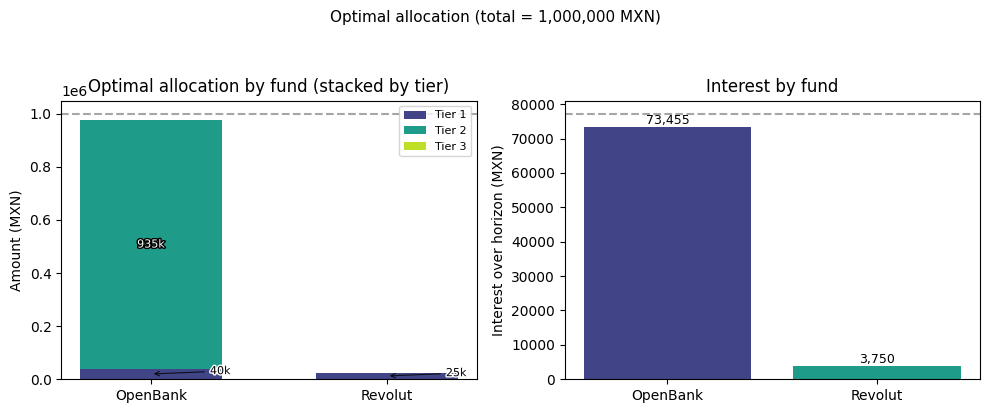

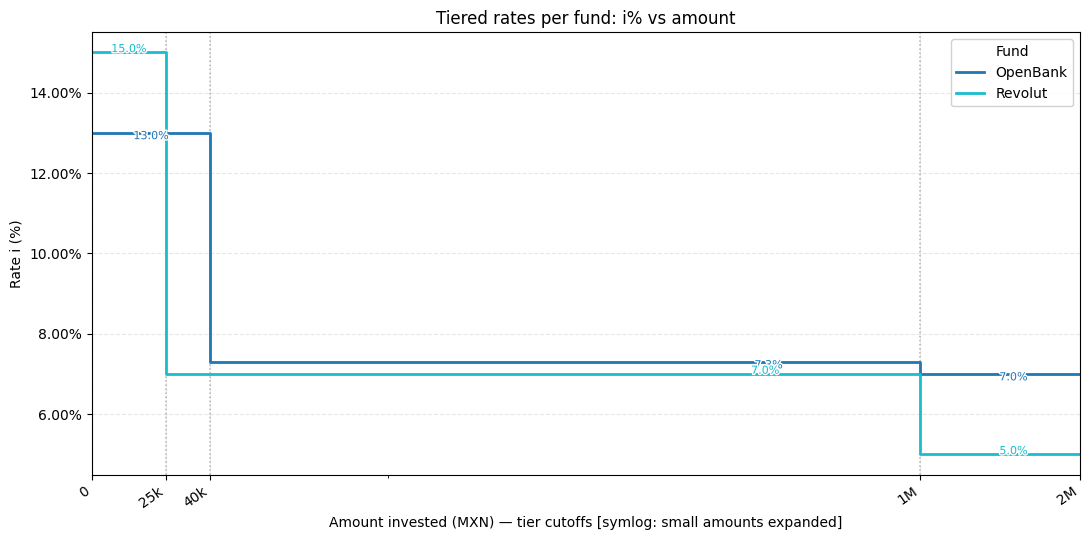

In [269]:
fund_a = [ # OpenBank
    (40_000, 0.13),
    (1_000_000, 0.073),
    (float("inf"), 0.07),
]
fund_b = [ # Revolut
    (25_000, 0.15),
    (1_000_000, 0.07),
    (float("inf"), 0.05),
]

total = 1_000_000  # MXN
# Use your actual fund names so they appear in the output
fund_names_example = ["OpenBank", "Revolut"]
res = sofipo_optimal_allocation(total, [fund_a, fund_b], fund_names=fund_names_example)
print("Success:", res["success"])
print("Allocation (MXN):", res["allocation"])
print("Allocation (%):", res["allocation_pct"])
print("Allocation by tier (MXN):", res["allocation_by_tier"])
print("Total interest (MXN over horizon):", round(res["total_interest"], 2))
print("Total interest rate (%):", round(res["total_interest_rate_pct"], 2))
print("Interest by fund:", res["interest_by_fund"])

plot_allocation_result(res, total, title=f"Optimal allocation (total = {total:,.0f} MXN)")

# Chart: interest rate (Y) vs amount invested (X) for each fund
# X axis > 1M so tier rules (e.g. 0–40k, 40k–1M, 1M+) and decreasing rates are visible
plot_rate_structure([fund_a, fund_b], fund_names=fund_names_example, x_max=2_000_000)

Success: True
Allocation (MXN): {'Cetes Bonddia': 0.0, 'OpenBank': 40000.0, 'Revolut': 25000.0, 'Mifel (cuenta digital)': 135000.0}
Allocation (%): {'Cetes Bonddia': 0.0, 'OpenBank': 20.0, 'Revolut': 12.5, 'Mifel (cuenta digital)': 67.5}
Allocation by tier (MXN): {'Cetes Bonddia': [0.0], 'OpenBank': [40000.0, 0.0, 0.0], 'Revolut': [25000.0, 0.0, 0.0], 'Mifel (cuenta digital)': [0.0, 135000.0, 0.0]}
Total interest (MXN over horizon): 22450.0
Total interest rate (%): 11.22
Interest by fund: {'Cetes Bonddia': 0.0, 'OpenBank': 5200.0, 'Revolut': 3750.0, 'Mifel (cuenta digital)': 13500.0}


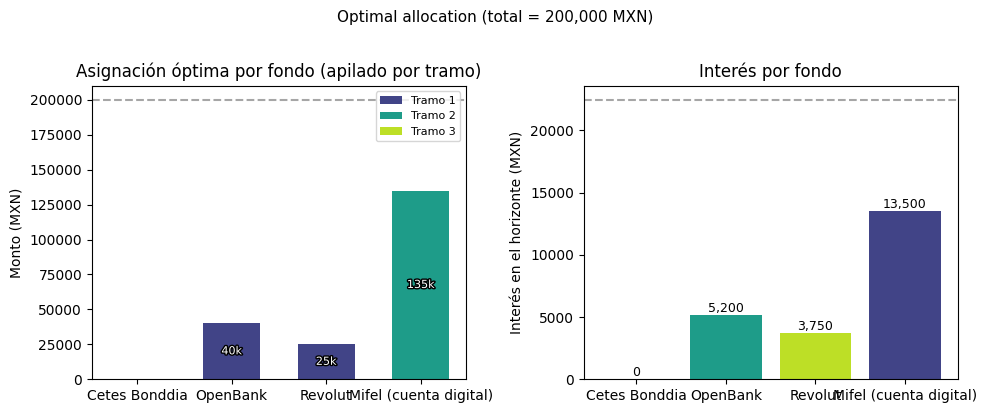

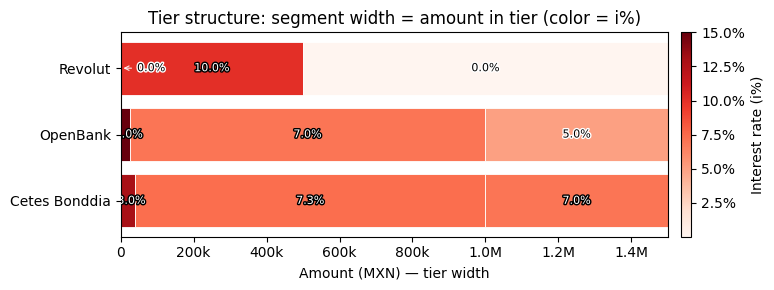

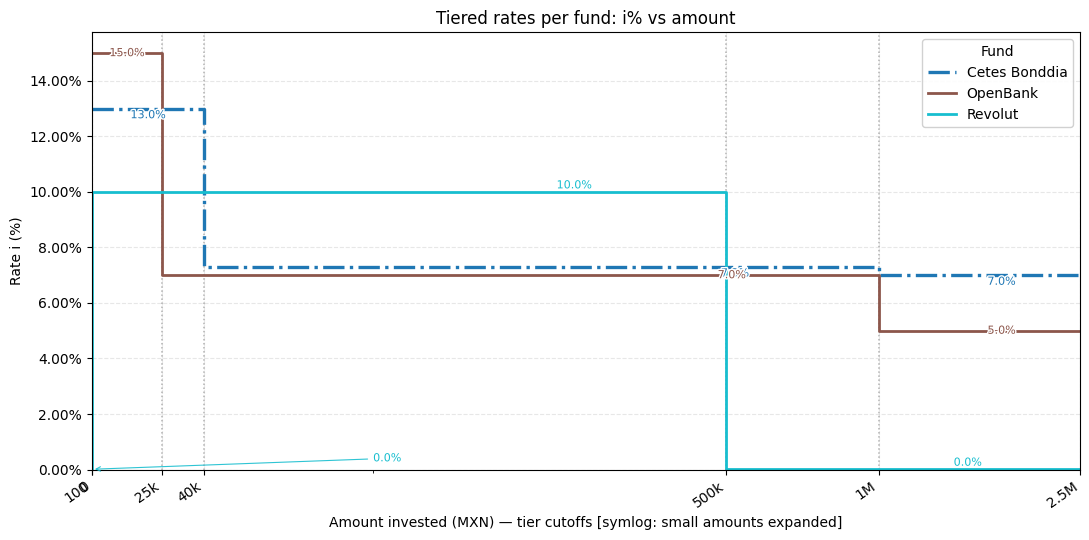

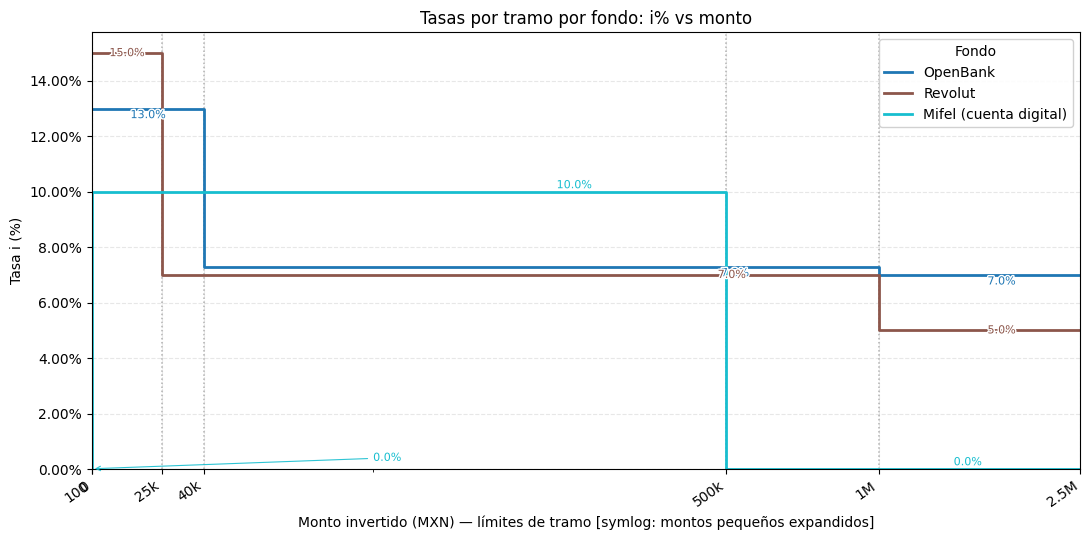

In [275]:
# three funds example
fund_a = [ # Cetes Bonddia
    (float("inf"), 0.0688),
]

fund_b = [ # OpenBank
    (40_000, 0.13),
    (1_000_000, 0.073),
    (float("inf"), 0.07),
]
fund_c = [ # Revolut
    (25_000, 0.15),
    (1_000_000, 0.07),
    (float("inf"), 0.05),
]

fund_d = [ # Mifel (cuenta digital)
    (99.99, 0.0001),
    (500_000, 0.10),
    (float("inf"), 0.0001),
]

total = 200_000  # MXN
# Use your actual fund names so they appear in the output
fund_names_example = ["Cetes Bonddia", "OpenBank", "Revolut", "Mifel (cuenta digital)"]
res = sofipo_optimal_allocation(total, [fund_a, fund_b, fund_c, fund_d], fund_names=fund_names_example)
print("Success:", res["success"])
print("Allocation (MXN):", res["allocation"])
print("Allocation (%):", res["allocation_pct"])
print("Allocation by tier (MXN):", res["allocation_by_tier"])
print("Total interest (MXN over horizon):", round(res["total_interest"], 2))
print("Total interest rate (%):", round(res["total_interest_rate_pct"], 2))
print("Interest by fund:", res["interest_by_fund"])

# charts
funds = [fund_b, fund_c, fund_d]
plot_allocation_result(res, total, title=f"Optimal allocation (total = {total:,.0f} MXN)", lang="es")
plot_tier_bars(funds, fund_names=fund_names_example, x_max=1_500_000)
plot_rate_structure(
    funds,
    fund_names=fund_names_example,
    benchmark_name="Cetes Bonddia",
)

plot_rate_structure(
    [fund_b, fund_c, fund_d],
    fund_names=["OpenBank", "Revolut", "Mifel (cuenta digital)"],
    lang="es",
)

Success: True
Allocation (MXN): {'Cetes 28': 0.0, 'OpenBank': 475000.0, 'Revolut': 25000.0, 'Mifel (cuenta digital)': 500000.0}
Allocation (%): {'Cetes 28': 0.0, 'OpenBank': 47.5, 'Revolut': 2.5, 'Mifel (cuenta digital)': 50.0}
Allocation by tier (MXN): {'Cetes 28': [0.0], 'OpenBank': [475000.0], 'Revolut': [25000.0, 0.0, 0.0], 'Mifel (cuenta digital)': [0.0, 500000.0, 0.0]}
Total interest (MXN over horizon): 96500.0
Total interest rate (%): 9.65
Interest by fund: {'Cetes 28': 0.0, 'OpenBank': 42750.0, 'Revolut': 3750.0, 'Mifel (cuenta digital)': 50000.0}


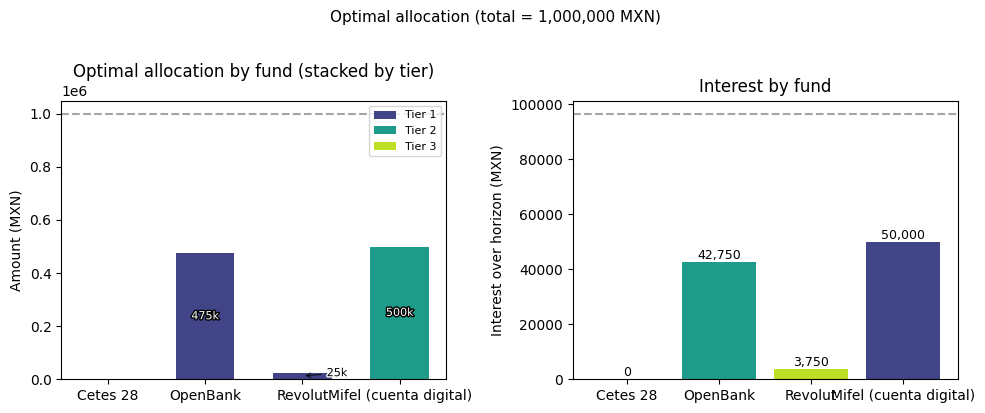

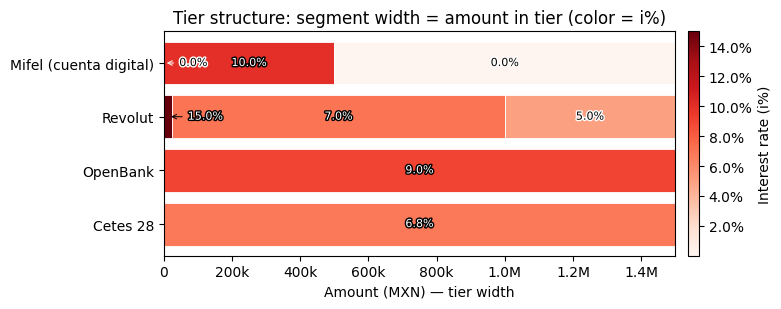

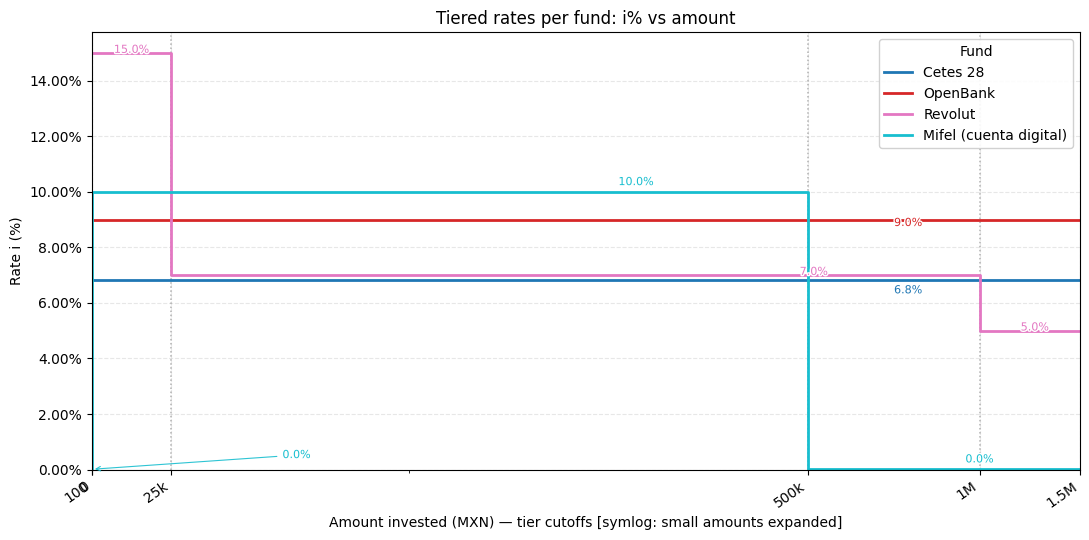

In [271]:
# Before 9% change in openbank
fund_a = [ # Cetes 28
    (float("inf"), 0.0681),
]

fund_b = [ # OpenBank
    (float("inf"), 0.09),
]
fund_c = [ # Revolut
    (25_000, 0.15),
    (1_000_000, 0.07),
    (float("inf"), 0.05),
]

fund_d = [ # Mifel (cuenta digital)
    (99.99, 0.0001),
    (500_000, 0.10),
    (float("inf"), 0.0001),
]

total = 1_000_000  # MXN
# Use your actual fund names so they appear in the output
fund_names_example = ["Cetes 28", "OpenBank", "Revolut", "Mifel (cuenta digital)"]
res = sofipo_optimal_allocation(total, [fund_a, fund_b, fund_c, fund_d], fund_names=fund_names_example)
print("Success:", res["success"])
print("Allocation (MXN):", res["allocation"])
print("Allocation (%):", res["allocation_pct"])
print("Allocation by tier (MXN):", res["allocation_by_tier"])
print("Total interest (MXN over horizon):", round(res["total_interest"], 2))
print("Total interest rate (%):", round(res["total_interest_rate_pct"], 2))
print("Interest by fund:", res["interest_by_fund"])

# charts
funds = [fund_a, fund_b, fund_c, fund_d]
plot_allocation_result(res, total, title=f"Optimal allocation (total = {total:,.0f} MXN)")
plot_tier_bars(funds, fund_names=fund_names_example, x_max=1_500_000)
plot_rate_structure(funds, fund_names=fund_names_example, x_max=1_500_000, log_x=True)


Success: True
Allocation (MXN): {'Cetes Bonddia': 0.0, 'OpenBank': 475000.0, 'Revolut': 25000.0, 'Mifel (cuenta digital)': 500000.0}
Allocation (%): {'Cetes Bonddia': 0.0, 'OpenBank': 47.5, 'Revolut': 2.5, 'Mifel (cuenta digital)': 50.0}
Allocation by tier (MXN): {'Cetes Bonddia': [0.0], 'OpenBank': [40000.0, 435000.0, 0.0], 'Revolut': [25000.0, 0.0, 0.0], 'Mifel (cuenta digital)': [0.0, 500000.0, 0.0]}
Total interest (MXN over horizon): 90705.0
Total interest rate (%): 9.07
Interest by fund: {'Cetes Bonddia': 0.0, 'OpenBank': 36954.99999999999, 'Revolut': 3750.0, 'Mifel (cuenta digital)': 50000.0}


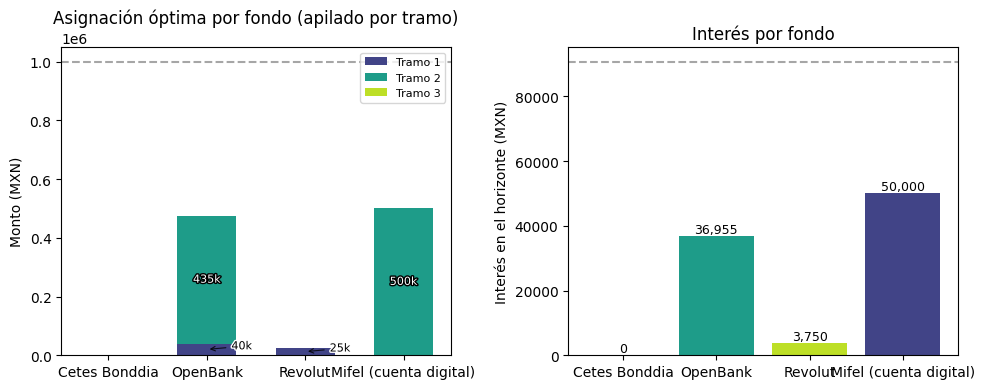

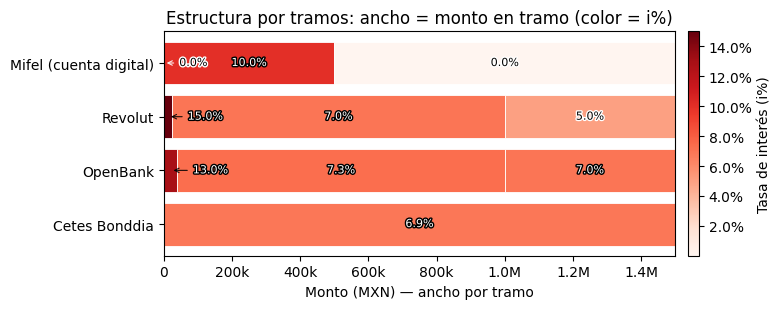

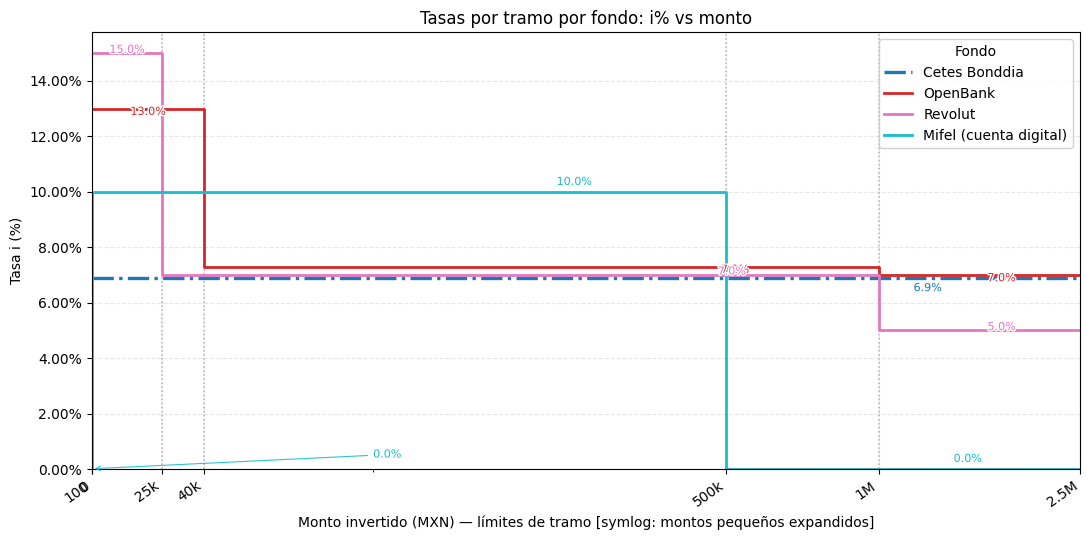

In [289]:
# select funds for linkedin post
fund_a = [ # Cetes Bonddia
    (float("inf"), 0.0688),
]

fund_b = [ # OpenBank
    (40_000, 0.13),
    (1_000_000, 0.073),
    (float("inf"), 0.07),
]
fund_c = [ # Revolut
    (25_000, 0.15),
    (1_000_000, 0.07),
    (float("inf"), 0.05),
]

fund_d = [ # Mifel (cuenta digital)
    (99.99, 0.0001),
    (500_000, 0.10),
    (float("inf"), 0.0001),
]

fund_e = [ # Didi
    (10_000, 0.15),
    (float("inf"), 0.075),
]

fund_f = [ # Klar Plus Platino
    (15_000, 0.15),
    (float("inf"), 0.08),
]

total = 1_000_000  # MXN
funds = [fund_a, fund_b, fund_c, fund_d]
fund_names_example = ["Cetes Bonddia", "OpenBank", "Revolut", "Mifel (cuenta digital)"]


# Use your actual fund names so they appear in the output
res = sofipo_optimal_allocation(total, funds, fund_names=fund_names_example)
print("Success:", res["success"])
print("Allocation (MXN):", res["allocation"])
print("Allocation (%):", res["allocation_pct"])
print("Allocation by tier (MXN):", res["allocation_by_tier"])
print("Total interest (MXN over horizon):", round(res["total_interest"], 2))
print("Total interest rate (%):", round(res["total_interest_rate_pct"], 2))
print("Interest by fund:", res["interest_by_fund"])

# charts
plot_allocation_result(res, total, lang="es")
plot_tier_bars(funds, fund_names=fund_names_example, x_max=1_500_000, lang="es")
plot_rate_structure(
    funds,
    fund_names=fund_names_example,
    benchmark_name="Cetes Bonddia",
    lang="es",
)

Success: True
Allocation (MXN): {'OpenBank': 900000.0}
Allocation (%): {'OpenBank': 100.0}
Allocation by tier (MXN): {'OpenBank': [40000.0, 860000.0, 0.0]}
Total interest (MXN over horizon): 67980.0
Total interest rate (%): 7.55
Interest by fund: {'OpenBank': 67980.0}


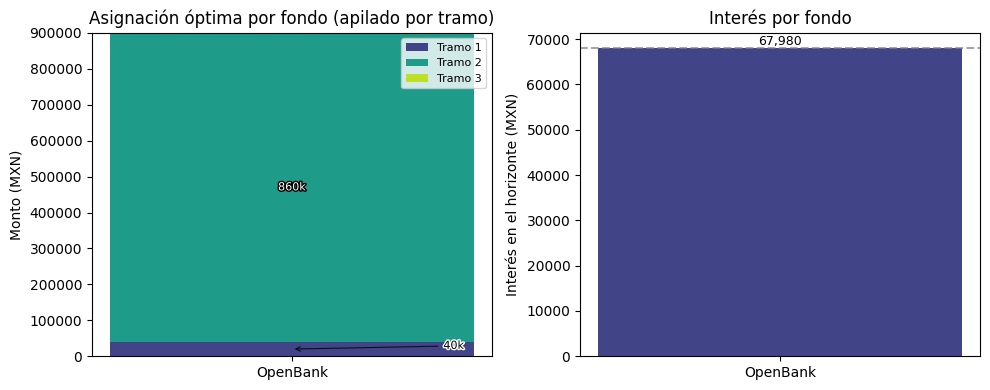

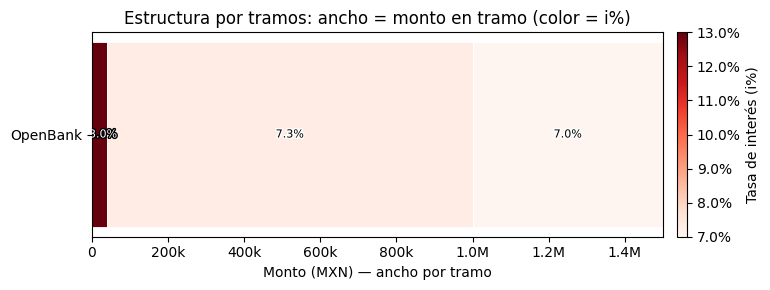

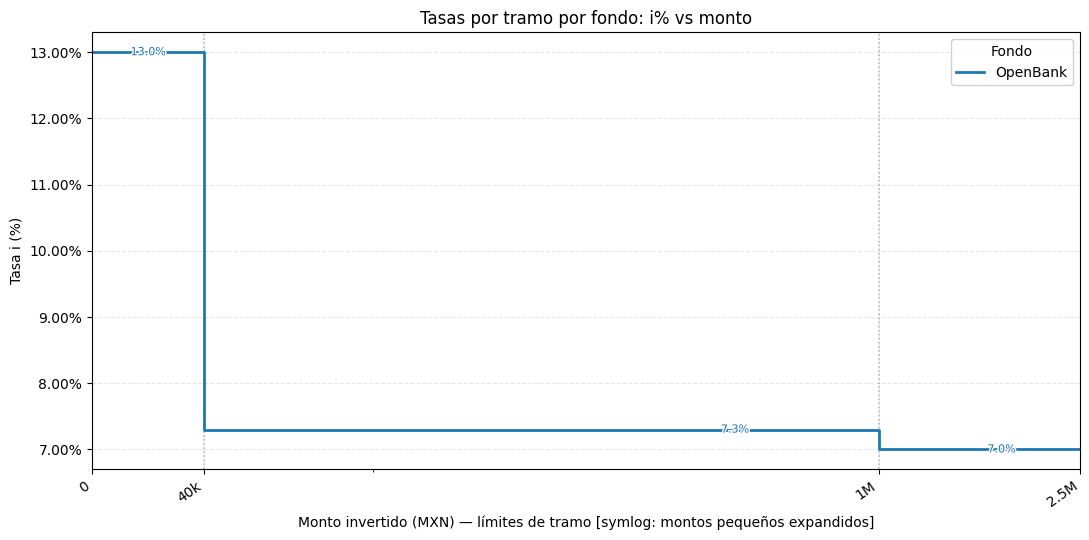

In [287]:
# select funds for linkedin post
fund_a = [ # Cetes Bonddia
    (float("inf"), 0.0688),
]

fund_b = [ # OpenBank
    (40_000, 0.13),
    (1_000_000, 0.073),
    (float("inf"), 0.07),
]
fund_c = [ # Revolut
    (25_000, 0.15),
    (1_000_000, 0.07),
    (float("inf"), 0.05),
]

fund_d = [ # Mifel (cuenta digital)
    (99.99, 0.0001),
    (500_000, 0.10),
    (float("inf"), 0.0001),
]

fund_e = [ # Didi
    (10_000, 0.15),
    (float("inf"), 0.075),
]

fund_f = [ # Klar Plus Platino
    (15_000, 0.15),
    (float("inf"), 0.08),
]

total = 900_000  # MXN
funds = [fund_b]
fund_names_example = ["OpenBank"]


# Use your actual fund names so they appear in the output
res = sofipo_optimal_allocation(total, funds, fund_names=fund_names_example)
print("Success:", res["success"])
print("Allocation (MXN):", res["allocation"])
print("Allocation (%):", res["allocation_pct"])
print("Allocation by tier (MXN):", res["allocation_by_tier"])
print("Total interest (MXN over horizon):", round(res["total_interest"], 2))
print("Total interest rate (%):", round(res["total_interest_rate_pct"], 2))
print("Interest by fund:", res["interest_by_fund"])

# charts
plot_allocation_result(res, total, lang="es")
plot_tier_bars(funds, fund_names=fund_names_example, x_max=1_500_000, lang="es")
plot_rate_structure(
    funds,
    fund_names=fund_names_example,
    benchmark_name="Cetes Bonddia",
    lang="es",
)

In [288]:
(67_980) - 83_405

-15425

In [ ]:
# env
import sys
print(sys.executable)

/Users/gera.ledesma/Desktop/Projects/sofipo/.venv/bin/python
